In [49]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

In [50]:

train_succ_base="data/baseline/Baseline_1time_succ_rate_training_nEnvs_1024_nEvalEnvs_10_gstepsperiter_102400_lr_0.0003_clipCoef_0.2_vfCoef_0.5_entCoef_0.0_Kepochs_8_nMB_32.csv"
train_rtn_base="data/baseline/Baseline_training_returns_OpenCabinetDrawer-v1__ppo__1__1745160198_nEnvs_1024_nEvalEnvs_10_gstepsperiter_102400_lr_0.0003_clipCoef_0.2_vfCoef_0.5_entCoef_0.0_Kepochs_8_nMB_32.csv"

eval_rtn_base="data/baseline/baseline_eval_return_OpenCabinetDrawer-v1__ppo__1__1745160198_nEnvs_1024_nEvalEnvs_10_gstepsperiter_102400_lr_0.0003_clipCoef_0.2_vfCoef_0.5_entCoef_0.0_Kepochs_8_nMB_32.csv"

eval_succ_base="data/baseline/baseline_eval_success_rateOpenCabinetDrawer-v1__ppo__1__1745160198_nEnvs_1024_nEvalEnvs_10_gstepsperiter_102400_lr_0.0003_clipCoef_0.2_vfCoef_0.5_entCoef_0.0_Kepochs_8_nMB_32.csv"


Tuning clip epsilon for policy loss

In [60]:

succ_rate_files = [
    "data/clip_coef_tuning/clipCoef_0.1_eval_succ_rate.csv",
    "data/clip_coef_tuning/clipCoef_0.1_train_succ_rate.csv",
    # "data/clip_coef_tuning/clipCoef_0.3_eval_succ_rate.csv",
    # "data/clip_coef_tuning/clipCoef_0.3_train_succ_rate.csv",
    eval_succ_base,
    train_succ_base,
    "data/clip_coef_tuning/eval_clip_0.4_succ.csv",
    "data/clip_coef_tuning/train_clip_0.4_succ.csv",

]
return_files = [
    "data/clip_coef_tuning/clipCoef_0.1_eval_returns.csv",
    "data/clip_coef_tuning/clipCoef_0.1_train_return.csv",
    # "data/clip_coef_tuning/clipCoef_0.3_eval_returns.csv",
    # "data/clip_coef_tuning/clipCoef_0.3_train_return.csv",
    eval_rtn_base,
    train_rtn_base,
    "data/clip_coef_tuning/eval_clip_0.4_rtn.csv",
    "data/clip_coef_tuning/train_clip_0.4_rtn.csv",
]

succ_labels = [
    "clip=0.1 - Eval",
    "clip=0.1 - Train",
    # "clip=0.3 - Eval",
    # "clip=0.3 - Train",
    "clip=0.2 - Eval",
    "clip=0.2 - Train",
    "clip=0.4 - Eval",
    "clip=0.4 - Train",
    "clip=1.0 - Eval",
    "clip=1.0 - Train"
]

return_labels = [
    "clip=0.1 - Eval",
    "clip=0.1 - Train",
    # "clip=0.3 - Eval",
    # "clip=0.3 - Train",
    "clip=0.2 - Eval",
    "clip=0.2 - Train",
    "clip=0.4 - Eval",
    "clip=0.4 - Train",
    "clip=1.0 - Eval",
    "clip=1.0 - Train"
]

colors=["blue", "blue",
        # "orange", "orange",
        "green", "green",
        "purple", "purple"]
linestyles=["-","--",
            # "-","--",
            "-","--",
            "-","--"]
alphas = [
    1.0, 0.4, 
    # 1.0, 0.4,  
    1.0, 0.4,
    1.0, 0.4  
]



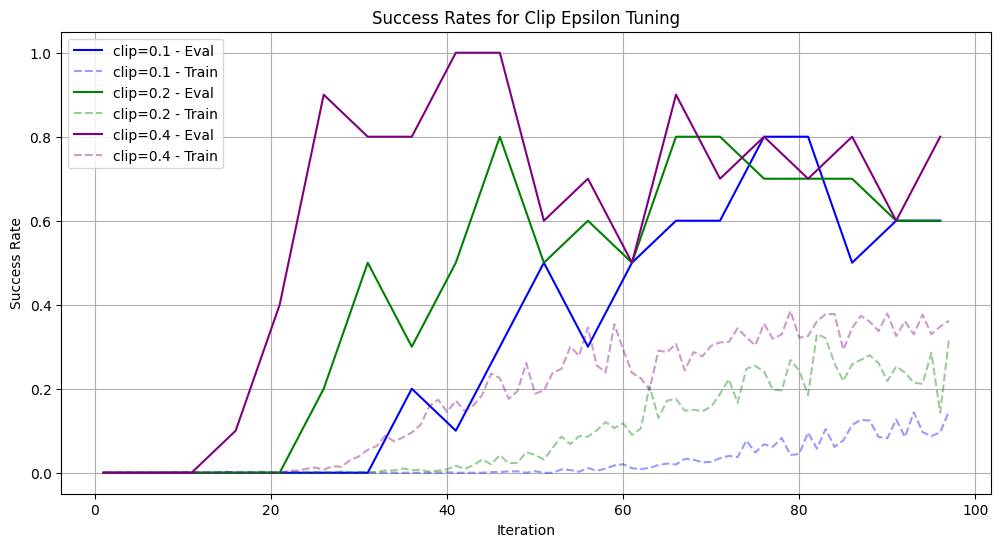

In [61]:
plt.figure(figsize=(12, 6))
for i in range(len(succ_rate_files)):
    df_eval_rtn = pd.read_csv(succ_rate_files[i])  
   
    plt.plot(df_eval_rtn["Step"], df_eval_rtn['Value'], label=succ_labels[i],color=colors[i], linestyle=linestyles[i], alpha=alphas[i])

# Customize plot
plt.xlabel("Iteration")
plt.ylabel("Success Rate")
plt.title("Success Rates for Clip Epsilon Tuning")
plt.grid(True)
plt.legend()
plt.savefig("clip_eps_succ_rates.png")

plt.show()

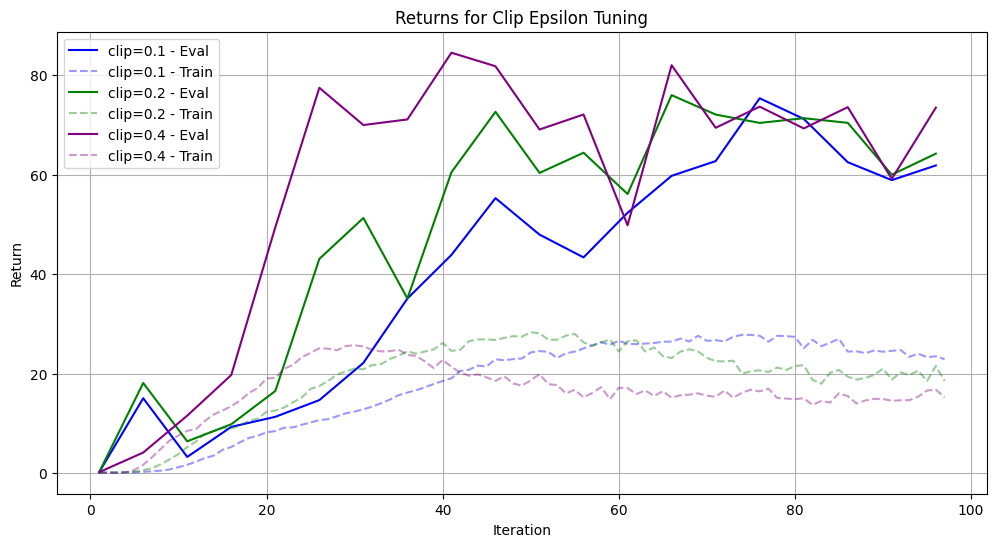

In [62]:
plt.figure(figsize=(12, 6))
for i in range(len(return_files)):
    df_return = pd.read_csv(return_files[i])  
    plt.plot(df_return["Step"], df_return["Value"], label=return_labels[i],
             color=colors[i], linestyle=linestyles[i],alpha=alphas[i])

# Customize plot
plt.xlabel("Iteration")
plt.ylabel("Return")
plt.title("Returns for Clip Epsilon Tuning")
plt.grid(True)
plt.legend()
plt.savefig("clip_eps_returns.png")

plt.show()

Tuning Parallel Envs

In [63]:
succ_rate_files = [
"data/parallel_env_tuning/eval_succ/OpenCabinetDrawer-v1__ppo__1__1745160198_nEnvs_1024_nEvalEnvs_10_gstepsperiter_102400_lr_0.0003_clipCoef_0.2_vfCoef_0.5_entCoef_0.0_Kepochs_8_nMB_32.csv",
"data/parallel_env_tuning/train_succ/OpenCabinetDrawer-v1__ppo__1__1745160198_nEnvs_1024_nEvalEnvs_10_gstepsperiter_102400_lr_0.0003_clipCoef_0.2_vfCoef_0.5_entCoef_0.0_Kepochs_8_nMB_32.csv",
"data/parallel_env_tuning/eval_succ/OpenCabinetDrawer-v1__ppo__1__1745171370_nEnvs_128_nEvalEnvs_10_gstepsperiter_12800_lr_0.0003_clipCoef_0.2_vfCoef_0.5_entCoef_0.0_Kepochs_8_nMB_32.csv",
"data/parallel_env_tuning/train_succ/OpenCabinetDrawer-v1__ppo__1__1745171370_nEnvs_128_nEvalEnvs_10_gstepsperiter_12800_lr_0.0003_clipCoef_0.2_vfCoef_0.5_entCoef_0.0_Kepochs_8_nMB_32.csv",
"data/parallel_env_tuning/eval_succ/OpenCabinetDrawer-v1__ppo__1__1745176881_nEnvs_512_nEvalEnvs_10_gstepsperiter_51200_lr_0.0003_clipCoef_0.2_vfCoef_0.5_entCoef_0.0_Kepochs_8_nMB_32.csv",
"data/parallel_env_tuning/train_succ/OpenCabinetDrawer-v1__ppo__1__1745176881_nEnvs_512_nEvalEnvs_10_gstepsperiter_51200_lr_0.0003_clipCoef_0.2_vfCoef_0.5_entCoef_0.0_Kepochs_8_nMB_32.csv"

]
return_files = [
"data/parallel_env_tuning/eval_returns/OpenCabinetDrawer-v1__ppo__1__1745160198_nEnvs_1024_nEvalEnvs_10_gstepsperiter_102400_lr_0.0003_clipCoef_0.2_vfCoef_0.5_entCoef_0.0_Kepochs_8_nMB_32.csv",
"data/parallel_env_tuning/train_returns/OpenCabinetDrawer-v1__ppo__1__1745160198_nEnvs_1024_nEvalEnvs_10_gstepsperiter_102400_lr_0.0003_clipCoef_0.2_vfCoef_0.5_entCoef_0.0_Kepochs_8_nMB_32.csv",
"data/parallel_env_tuning/eval_returns/OpenCabinetDrawer-v1__ppo__1__1745171370_nEnvs_128_nEvalEnvs_10_gstepsperiter_12800_lr_0.0003_clipCoef_0.2_vfCoef_0.5_entCoef_0.0_Kepochs_8_nMB_32.csv",
"data/parallel_env_tuning/train_returns/OpenCabinetDrawer-v1__ppo__1__1745171370_nEnvs_128_nEvalEnvs_10_gstepsperiter_12800_lr_0.0003_clipCoef_0.2_vfCoef_0.5_entCoef_0.0_Kepochs_8_nMB_32.csv",
"data/parallel_env_tuning/eval_returns/OpenCabinetDrawer-v1__ppo__1__1745176881_nEnvs_512_nEvalEnvs_10_gstepsperiter_51200_lr_0.0003_clipCoef_0.2_vfCoef_0.5_entCoef_0.0_Kepochs_8_nMB_32.csv",
"data/parallel_env_tuning/train_returns/OpenCabinetDrawer-v1__ppo__1__1745176881_nEnvs_512_nEvalEnvs_10_gstepsperiter_51200_lr_0.0003_clipCoef_0.2_vfCoef_0.5_entCoef_0.0_Kepochs_8_nMB_32.csv",

]
succ_labels = [
    "nEnvs=1024 - Eval Success Rate", "nEnvs=1024 - Train Success Rate",
    "nEnvs=128 - Eval Success Rate",  "nEnvs=128 - Train Success Rate",
    "nEnvs=512 - Eval Success Rate",  "nEnvs=512 - Train Success Rate"
]

return_labels = [
    "nEnvs=1024 - Eval Return", "nEnvs=1024 - Train Return",
    "nEnvs=128 - Eval Return",  "nEnvs=128 - Train Return",
    "nEnvs=512 - Eval Return",  "nEnvs=512 - Train Return"
]

# Plot styles
colors = ["blue", "blue", "orange", "orange", "green", "green"]
linestyles = ["-", "--", "-", "--", "-", "--"]

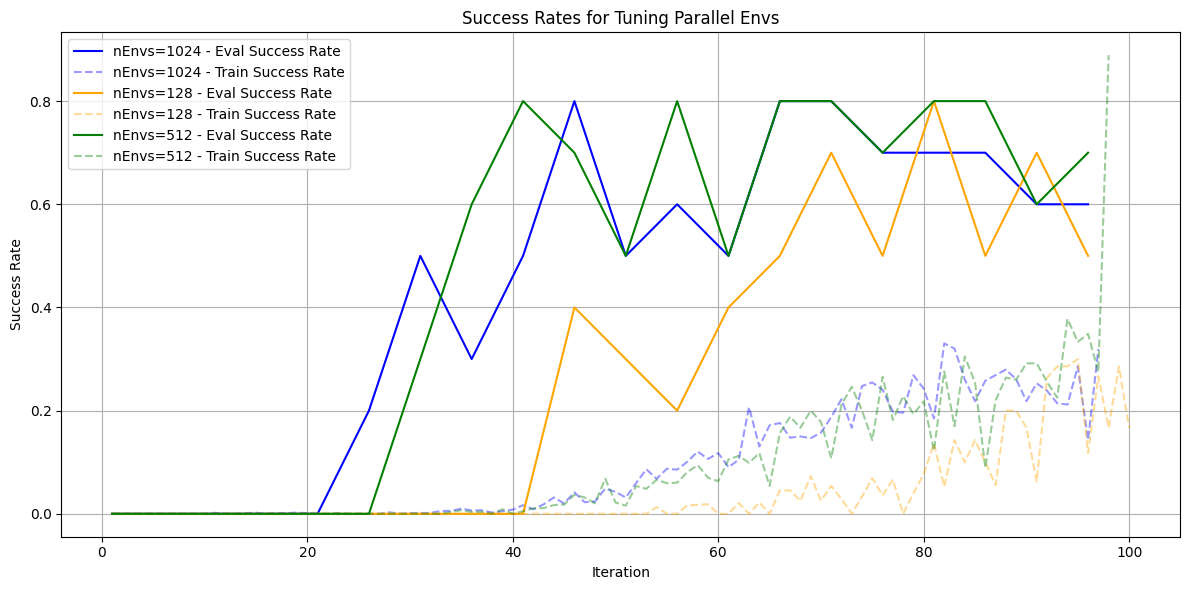

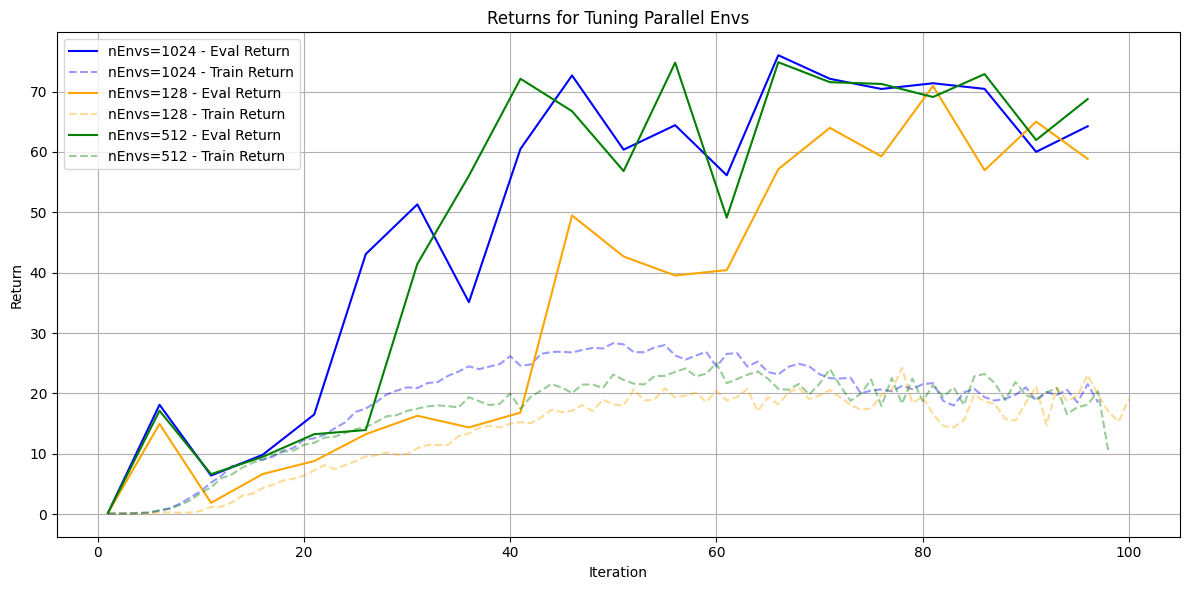

In [64]:
plt.figure(figsize=(12, 6))
for i, file in enumerate(succ_rate_files):
    df = pd.read_csv(file)
    df = df[df["Step"] <= 100]
    plt.plot(df["Step"], df["Value"], label=succ_labels[i], color=colors[i], linestyle=linestyles[i],alpha=alphas[i])
plt.xlabel("Iteration")
plt.ylabel("Success Rate")
plt.title("Success Rates for Tuning Parallel Envs")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig("parallel_envs_succ_rates.png")
plt.show()

# Plot return
plt.figure(figsize=(12, 6))
for i, file in enumerate(return_files):
    df = pd.read_csv(file)
    df = df[df["Step"] <= 100]
    plt.plot(df["Step"], df["Value"], label=return_labels[i], color=colors[i], linestyle=linestyles[i],alpha=alphas[i])
plt.xlabel("Iteration")
plt.ylabel("Return")
plt.title("Returns for Tuning Parallel Envs")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig("parallel_envs_returns.png")
plt.show()

Tuning Value Coefficient